In [23]:
# fonction.py est resté à la racine du projet (partagé par tous les
# notebooks) : chaque notebook vivant maintenant dans son propre
# dossier, on ajoute le dossier parent au chemin d'import.
import sys, os
sys.path.append(os.path.abspath('..'))

from fonction import *

### Étude de sensibilité : différents scénarios physiques

Pour mieux comprendre le rôle de chaque paramètre du modèle, on simule
plusieurs scénarios en faisant varier D (diffusion), α (amortissement),
σ (largeur initiale du choc) et le nombre de Courant `clf`. On inclut
notamment un scénario **instable** (CFL > 0.5) pour illustrer concrètement
la condition de stabilité.

In [24]:
scenarios = {
    "Diffusion pure (alpha=0)":       dict(D=1.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance dominante":         dict(D=0.2, alpha=1.0,  sigma=1.0, clf=0.45),
    "Diffusion rapide":               dict(D=5.0, alpha=0.1,  sigma=1.0, clf=0.45),
    "Front raide":                    dict(D=1.0, alpha=0.1,  sigma=0.3, clf=0.45),
    "Front large":                    dict(D=1.0, alpha=0.1,  sigma=3.0, clf=0.45),
    "Diffusion lente":                dict(D=0.05, alpha=0.1, sigma=1.0, clf=0.45),
    "Décroissance nulle + rapide":    dict(D=5.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance forte + lente":     dict(D=0.05, alpha=1.0, sigma=1.0, clf=0.45),
    "CFL limite (0.5)":               dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.5),
    "Instable (CFL > 0.5)":           dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.6),
}

model, stats = charger_mlp('../mlp_reference.pth')
x_mean, x_std = stats['x_mean'], stats['x_std']
t_mean, t_std = stats['t_mean'], stats['t_std']
u_mean, u_std, eps = stats['u_mean'], stats['u_std'], stats['eps']
# ... le reste de la cellule ne change pas
temps_a_tracer = [0.0, 0.2, 1.0, 2.0, 5.0]
       

###  Version "scénario" du résidu et de la loss du PINN

Identique à `pinn_residual` / `pinn_loss` (définies dans `fonction.py`), mais
avec `D` et `alpha` comme arguments explicites à chaque appel, pour pouvoir
ré-entraîner un PINN différent pour chaque scénario physique dans la boucle
de la cellule 11, sans dépendre des variables globales `D`, `alpha`.

In [25]:

pinn, pinn_meta = charger_pinn('../pinn_reference.pth')   # <-- charger_pinn renvoie désormais (model, meta)
model, stats = charger_mlp('../mlp_reference.pth')

# t_vf est déjà mesuré dans MLP.ipynb (cellule 26) ; on le remesure ici,
# indépendamment, pour ne pas dépendre de l'ordre d'exécution des notebooks
# (u_volume_finie() étant peu coûteux, remesurer ne pose pas de problème).
t0 = time.perf_counter()
x_grille, t_grille, U_vf_grille = u_volume_finie()
t_vf = time.perf_counter() - t0

# Exposés en variables globales "nues" (sans underscore) pour que la
# cellule 13 les retrouve via globals().get('t_train_mlp', np.nan), etc.
t_train_mlp = stats['t_train_mlp']
t_adam = pinn_meta['t_adam']
t_lbfgs = pinn_meta['t_lbfgs']

X_mesh, T_mesh = np.meshgrid(x_grille, t_grille)
U_mlp_grille = predire_mlp(model, stats, X_mesh, T_mesh)
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
dx_grille = x_grille[1] - x_grille[0]
# ... le reste de la cellule ne change pas

## Conclusion : Analytique vs Volumes Finis vs MLP vs PINN, sur tous les scénarios

Pour clore la comparaison, on reprend trois scénarios physiques
représentatifs de la section 18 (un par grande famille de comportement :
décroissance dominante, diffusion rapide, front raide), et pour chacun
on calcule les 4 solutions :
- **Analytique** et **Volumes Finis** : recalculées pour CE scénario (référence fiable) ;
- **MLP** : le modèle fixe entraîné une seule fois — on s'attend à ce qu'il
  se dégrade dès qu'on s'éloigne du régime d'entraînement ;
- **PINN** : ré-entraîné spécifiquement pour CE scénario (via `train_pinn_scenario`),
  car le résidu de l'EDP dépend de D et alpha — le PINN peut donc s'adapter
  à n'importe quel jeu de paramètres sans changer d'architecture.

C'est la démonstration attendue en conclusion du stage : le PINN combine
la flexibilité du Deep Learning avec le respect de la physique, là où le
MLP purement supervisé ne généralise pas.

In [26]:



def train_pinn_scenario(D, alpha, sigma, A=A, x0=x0, L=L, T=T,
                        epochs=2000, lr=1e-3, lambda_pde=8.0,
                        N_ic=300, N_bc=300, N_r=500, N_lbfgs=2000,
                        lbfgs_iter=200, patience=200, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = PINN(hidden_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def colloc(n):
        # t = T*u^2 : points plus denses aux temps courts, où le pic s'effondre
        x = np.random.uniform(-L, L, n)
        t = T * np.random.uniform(0, 1, n) ** 2
        return torch.tensor(np.column_stack([x, t]), dtype=torch.float32)

    # --- Données IC (75% concentrées près du pic) + BC (Dirichlet analytique) ---
    n_focus = int(0.75 * N_ic)  
    x_ic = np.concatenate([np.random.uniform(-L, L, N_ic - n_focus),
                           np.clip(np.random.normal(x0, sigma, n_focus), -L, L)])
    t_ic = np.zeros(N_ic)
    dx_bc = 2 * L / Nx
    xb = L - dx_bc / 2          # = 9.95 avec Nx=200, L=10 — même point que les VF
    t_bc = np.random.uniform(0, T, N_bc)
    x_bc = np.where(np.arange(N_bc) < N_bc // 2, -xb, xb).astype(float)
    x_all = np.concatenate([x_ic, x_bc])
    t_all = np.concatenate([t_ic, t_bc])
    u_all = u_analytique(x_all, t_all, A, x0, sigma, D, alpha)
    X_data = torch.tensor(np.column_stack([x_all, t_all]), dtype=torch.float32)
    u_data = torch.tensor(u_all, dtype=torch.float32).view(-1, 1)

    # --- Phase 1 : Adam + arrêt anticipé (validation sur points fixes, même loi en t) ---
    X_val = colloc(2000)
    best_val, best_epoch, best_state = float('inf'), 0, None

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss_total, _, _ = pinn_loss_scenario(model, X_data, u_data, colloc(N_r),
                                              D, alpha, lambda_pde)
        loss_total.backward()
        optimizer.step()

        if epoch % 10 == 0:
            val = pinn_loss_scenario(model, X_data, u_data, X_val, D, alpha, lambda_pde)[0].item()
            if val < best_val * (1 - 1e-3):
                best_val, best_epoch = val, epoch
                best_state = snapshot_state_dict(model)  # copie réelle et indépendante
            if epoch - best_epoch >= patience:
                print(f"  arrêt anticipé à l'epoch {epoch} (meilleure : {best_epoch})")
                break

    assert best_state is not None, (
        "Aucun meilleur état mémorisé pendant l'entraînement du PINN scénario.")
    model.load_state_dict(best_state)      # <-- HORS de la boucle (4 espaces)

    # --- Phase 2 : L-BFGS sur points de collocation FIXES (2000, même loi en t) ---
    X_f = colloc(N_lbfgs)
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iter,
                              history_size=50, line_search_fn='strong_wolfe',
                              tolerance_grad=1e-12, tolerance_change=1e-14)

    def closure():
        lbfgs.zero_grad()
        loss = pinn_loss_scenario(model, X_data, u_data, X_f, D, alpha, lambda_pde)[0]
        loss.backward()
        return loss

    lbfgs.step(closure)
    return model

Décroissance dominante | 1500 epochs | temps PINN : 10.5 s | RMSE PINN = 1.913e-04 | L∞ = 6.944e-04


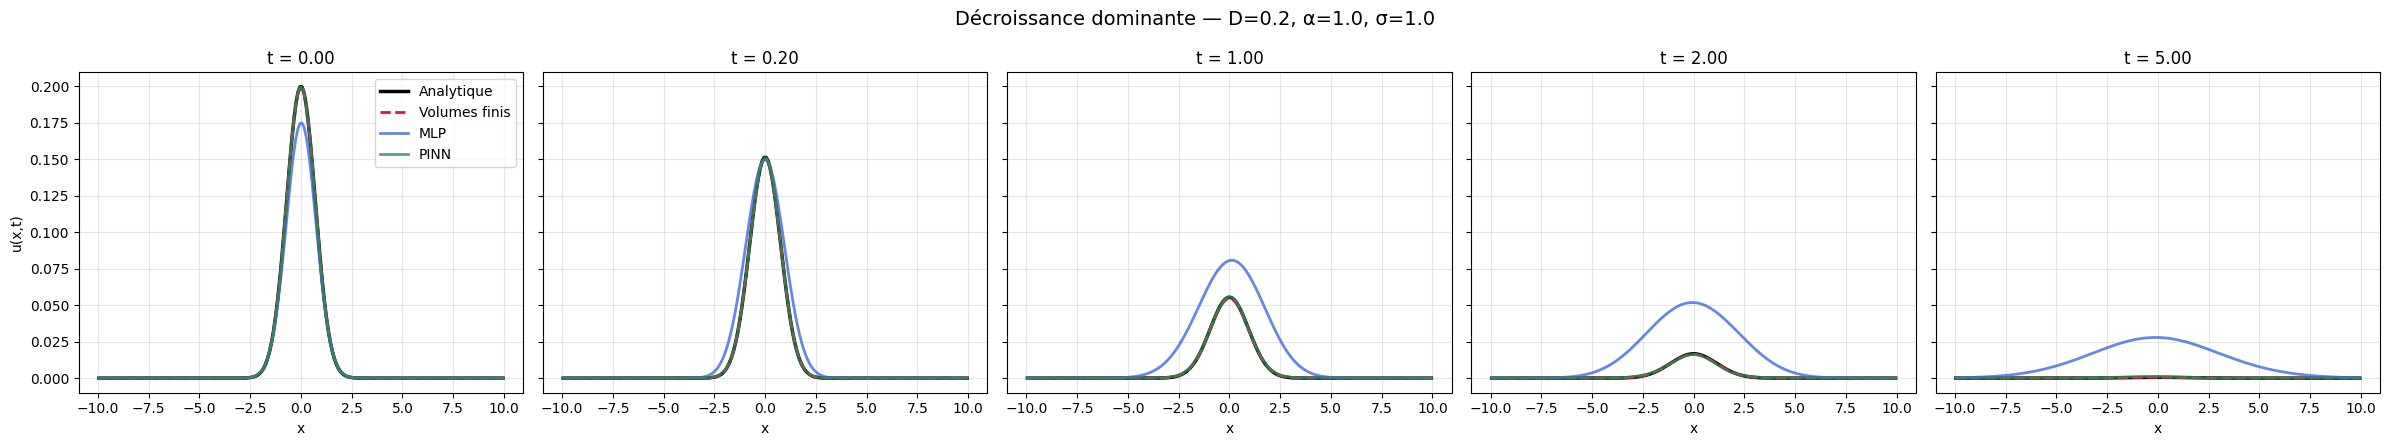

Diffusion rapide | 1500 epochs | temps PINN : 9.8 s | RMSE PINN = 1.320e-03 | L∞ = 3.414e-03


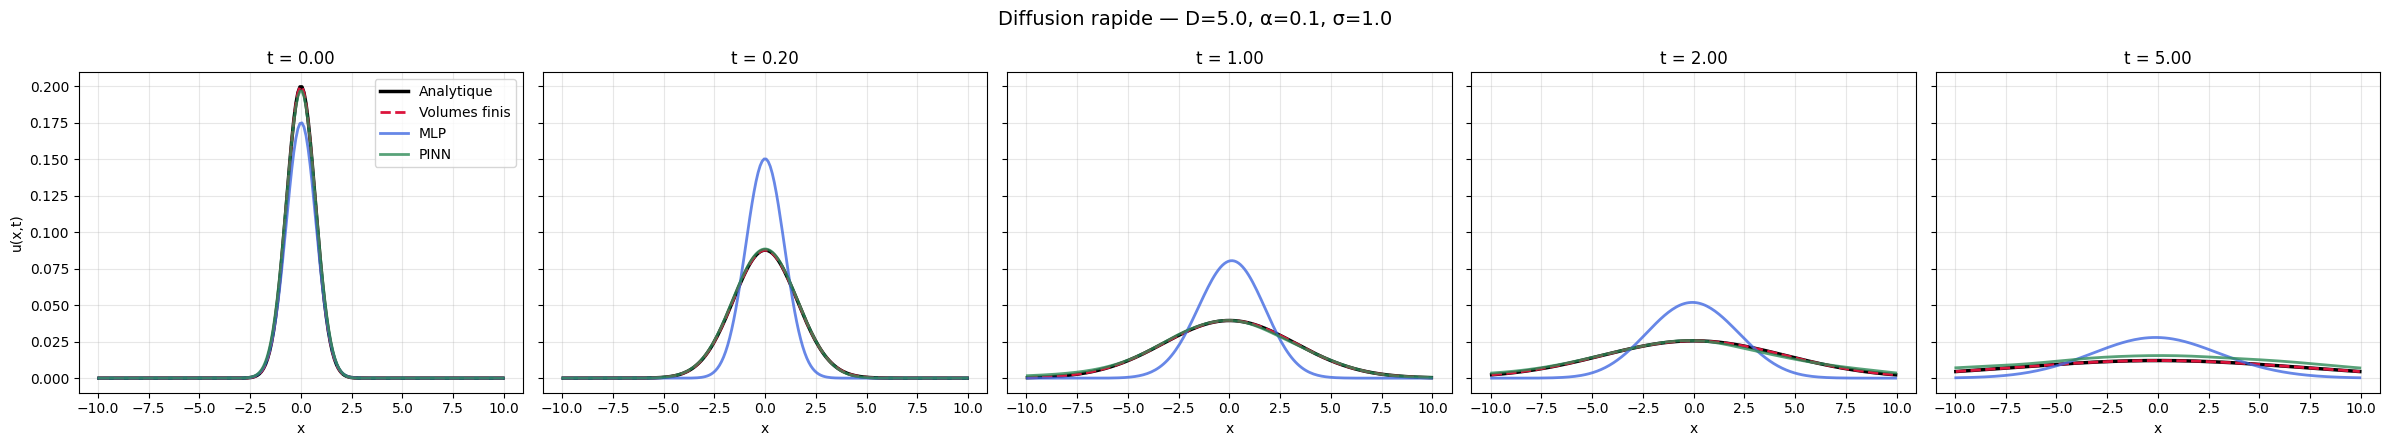

Front raide | 1500 epochs | temps PINN : 10.2 s | RMSE PINN = 2.514e-03 | L∞ = 1.246e-02


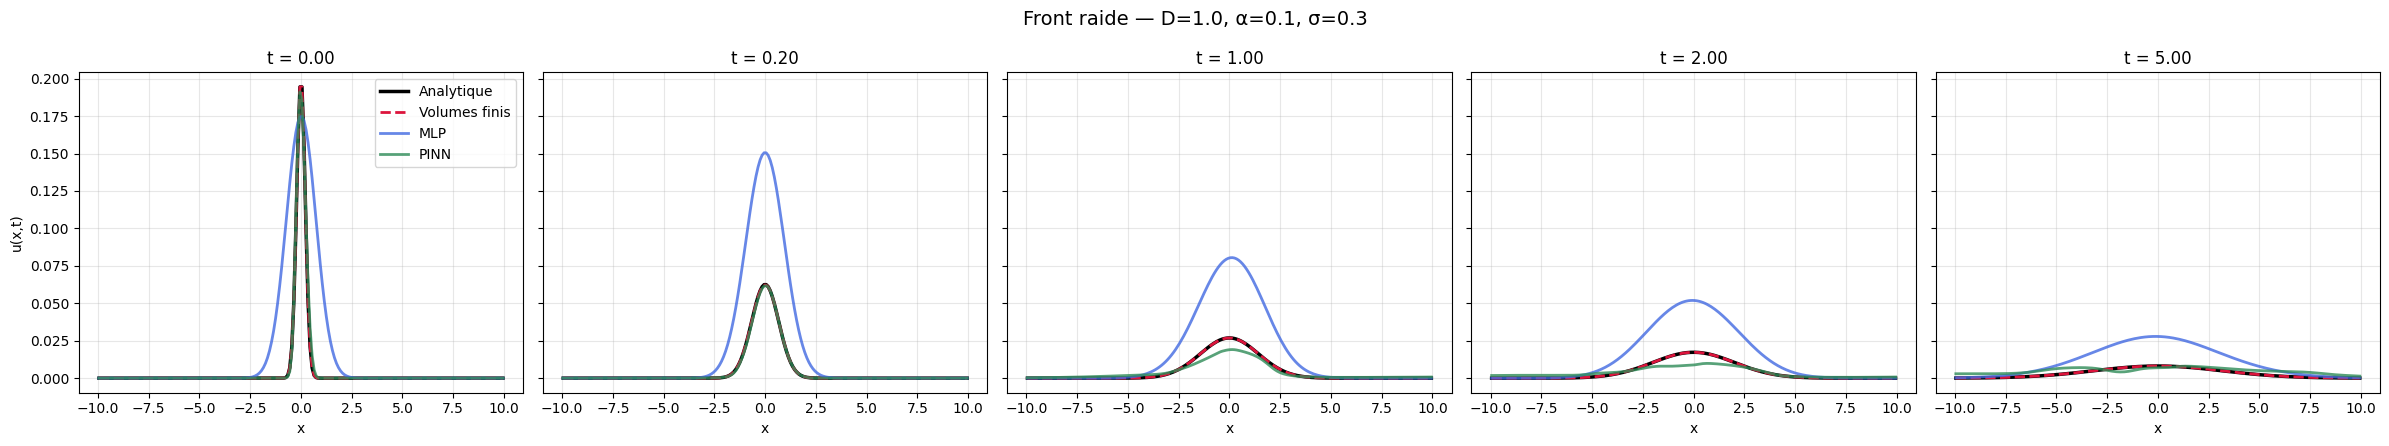

In [35]:
temps_a_tracer = [1e-4, 0.2, 1, 2, T]
EPOCHS_SC = 1500                      # à changer ici uniquement (800 à 1500)
resultats_sc = []

scenarios_test = {k: scenarios[k] for k in ["Décroissance dominante", "Diffusion rapide", "Front raide"]}
for nom, p in scenarios_test.items():
    D_s, alpha_s, sigma_s, clf_s = p["D"], p["alpha"], p["sigma"], p["clf"]

    # Volumes finis + analytique pour ce scénario
    x_VF, t_VF, U_num = u_volume_finie(A=A, x0=x0, sigma=sigma_s, D=D_s,
                                        alpha=alpha_s, L=L, T=T, Nx=Nx, clf=clf_s)

    # PINN entraîné spécifiquement pour ce scénario (chronométré)
    t0 = time.perf_counter()
    pinn_s = train_pinn_scenario(D=D_s, alpha=alpha_s, sigma=sigma_s,
                                 epochs=EPOCHS_SC, lambda_pde=3,
                                 N_ic=600, N_bc=300, N_r=500, N_lbfgs=2000)
    t_pinn_s = time.perf_counter() - t0

    # --- Erreurs des 3 méthodes sur la même grille (x_VF × t_VF[::10]) ---
    xx, tt = np.meshgrid(x_VF, t_VF[::10])
    ue = u_analytique(xx, tt, A, x0, sigma_s, D_s, alpha_s)
    pinn_s.eval(); model.eval()
    with torch.no_grad():
        up = pinn_s(torch.tensor(np.column_stack([xx.ravel(), tt.ravel()]),
                                 dtype=torch.float32)).numpy().reshape(xx.shape)
        # MLP entraîné une seule fois sur le régime de référence
        Xm = torch.tensor(np.column_stack([((xx - x_mean) / x_std).ravel(),
                                           ((tt - t_mean) / t_std).ravel()]), dtype=torch.float32)
        um = (np.exp(model(Xm).numpy().flatten() * u_std + u_mean) - eps).reshape(xx.shape)

    rm = lambda U: np.sqrt(np.mean((U - ue) ** 2))
    li = lambda U: np.abs(U - ue).max()
    print(f"{nom} | {EPOCHS_SC} epochs | temps PINN : {t_pinn_s:.1f} s | "
          f"RMSE PINN = {rm(up):.3e} | L∞ = {li(up):.3e}")
    resultats_sc.append((nom, rm(U_num[::10]), rm(um), rm(up),
                         li(U_num[::10]), li(um), li(up), t_pinn_s))

    # --- Tracé : MLP évalué sur CE scénario pour montrer qu'il ne s'adapte pas ---
    x_n = (x_VF - x_mean) / x_std

    fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(24, 4.5), sharey=True)

    for col, ti in enumerate(temps_a_tracer):
        ax = axes[col]
        idx = np.argmin(np.abs(t_VF - ti))

        # --- Analytique et Volumes Finis : propres à CE scénario ---
        u_exacte_ti = u_analytique(x_VF, t_VF[idx], A, x0, sigma_s, D_s, alpha_s)
        u_vf_ti = U_num[idx, :]

        # --- MLP : modèle fixe, évalué sur la grille de CE scénario ---
        t_n = (np.full_like(x_VF, t_VF[idx]) - t_mean) / t_std
        Xg = torch.tensor(np.column_stack([x_n, t_n]), dtype=torch.float32)
        with torch.no_grad():
            u_log_pred = model(Xg).numpy().flatten() * u_std + u_mean
        u_mlp_ti = np.exp(u_log_pred) - eps

        # --- PINN : ré-entraîné pour CE scénario ---
        with torch.no_grad():
            xt = torch.tensor(np.column_stack([x_VF, np.full_like(x_VF, t_VF[idx])]),
                              dtype=torch.float32)
            u_pinn_ti = pinn_s(xt).numpy().flatten()

        ax.plot(x_VF, u_exacte_ti, color='black', linewidth=2.5, label="Analytique")
        ax.plot(x_VF, u_vf_ti, color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
        ax.plot(x_VF, u_mlp_ti, color='royalblue', linewidth=2, alpha=0.8, label="MLP")
        ax.plot(x_VF, u_pinn_ti, color='seagreen', linewidth=2, alpha=0.8, label="PINN")

        ax.set_title(f"t = {ti:.2f}", fontsize=12)
        ax.set_xlabel('x'); ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('u(x,t)')
    axes[0].legend(fontsize=10)
    fig.suptitle(f"{nom} — D={D_s}, α={alpha_s}, σ={sigma_s}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'scenario_PINN_{nom[:15].replace(" ", "_")}.png', dpi=200, bbox_inches='tight')
    plt.show()

In [28]:
# ============================================================
# Tableau final : erreurs + temps (VF / MLP / PINN)
# ============================================================

import time
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# 1. Grille et solution exacte communes
# ------------------------------------------------------------

Xm, Tm = np.meshgrid(x_grille, t_grille)

U_ex = u_analytique(
    Xm, Tm,
    A, x0, sigma, D, alpha
)

dx_g = x_grille[1] - x_grille[0]


# ------------------------------------------------------------
# 2. Prédiction MLP
# ------------------------------------------------------------

def predire_mlp():

    xn = (Xm.ravel() - x_mean) / x_std
    tn = (Tm.ravel() - t_mean) / t_std

    X = torch.tensor(
        np.column_stack([xn, tn]),
        dtype=torch.float32
    )

    with torch.no_grad():
        ul = model(X).numpy().flatten() * u_std + u_mean

    return (np.exp(ul) - eps).reshape(Xm.shape)


# ------------------------------------------------------------
# 3. Prédiction PINN
# ------------------------------------------------------------

def predire_pinn():

    X = torch.tensor(
        np.column_stack([
            Xm.ravel(),
            Tm.ravel()
        ]),
        dtype=torch.float32
    )

    with torch.no_grad():
        return pinn(X).numpy().reshape(Xm.shape)


# ------------------------------------------------------------
# 4. Chronométrage
# ------------------------------------------------------------

def chrono(f, n=10):

    # Échauffement
    f()

    t0 = time.perf_counter()

    for _ in range(n):
        f()

    return (time.perf_counter() - t0) / n


# ------------------------------------------------------------
# 5. Métriques
# ------------------------------------------------------------

def metriques(U_pred):

    d = U_pred - U_ex

    RMSE = np.sqrt(np.mean(d**2))

    Linf = np.max(np.abs(d))

    L2 = np.sqrt(
        dx_g * np.sum(d**2, axis=1)
    ).max()

    return RMSE, Linf, L2


# ------------------------------------------------------------
# 6. Prédictions
# ------------------------------------------------------------

model.eval()
pinn.eval()

U_mlp = predire_mlp()
U_pinn = predire_pinn()


# ------------------------------------------------------------
# 7. Temps disponibles
# ------------------------------------------------------------

t_adam_ = globals().get('t_adam', np.nan)
t_lbfgs_ = globals().get('t_lbfgs', np.nan)

t_train_mlp_ = globals().get('t_train_mlp', np.nan)


# ------------------------------------------------------------
# 8. Temps du calcul VF
# ------------------------------------------------------------
# Si le temps VF n'a pas été mesuré précédemment,
# on le laisse à NaN plutôt que d'inventer une valeur.

t_vf_ = globals().get('t_vf', np.nan)


# ------------------------------------------------------------
# 9. Tableau final
# ------------------------------------------------------------

temps_pinn = (
    t_adam_ + t_lbfgs_
    if np.isfinite(t_adam_) and np.isfinite(t_lbfgs_)
    else np.nan
)

lignes = [

    (
        "Volumes finis",
        *metriques(U_vf_grille),
        t_vf_,
        np.nan
    ),

    (
        "MLP",
        *metriques(U_mlp),
        t_train_mlp_,
        chrono(predire_mlp)
    ),

    (
        "PINN (Adam+L-BFGS)",
        *metriques(U_pinn),
        temps_pinn,
        chrono(predire_pinn)
    )
]


df_final = pd.DataFrame(
    lignes,
    columns=[
        "Méthode",
        "RMSE",
        "L∞",
        "L2 max(t)",
        "Temps entraînement / calcul (s)",
        "Temps évaluation grille (s)"
    ]
)


# ------------------------------------------------------------
# 10. Sauvegarde
# ------------------------------------------------------------

df_final.to_csv(
    "tableau_final_methodes.csv",
    index=False
)


# ------------------------------------------------------------
# 11. Affichage
# ------------------------------------------------------------

display(
    df_final.style.format({
        "RMSE": "{:.3e}",
        "L∞": "{:.3e}",
        "L2 max(t)": "{:.3e}",
        "Temps entraînement / calcul (s)": "{:.2f}",
        "Temps évaluation grille (s)": "{:.4f}"
    }, na_rep="—").hide(axis="index")
)

print(
    f"Grille d'évaluation : {Xm.size} points "
    f"({len(t_grille)} instants × {len(x_grille)} positions)"
)

Méthode,RMSE,L∞,L2 max(t),Temps entraînement / calcul (s),Temps évaluation grille (s)
Volumes finis,1.666e-05,1.665e-04,1.822e-04,0.31,—
MLP,8.986e-04,2.506e-02,2.516e-02,4.05,0.0463
PINN (Adam+L-BFGS),1.994e-04,1.218e-03,1.442e-03,12.44,0.0443


Grille d'évaluation : 222400 points (1112 instants × 200 positions)


## Test hors distribution (OOD) — condition initiale à deux chocs gaussiens

Toutes les évaluations précédentes (MLP, PINN, y compris les 10 scénarios de sensibilité) utilisent une condition initiale à **un seul** choc gaussien : seuls les paramètres physiques (D, α, σ) changent, la *forme* de la donnée initiale reste identique à celle vue à l'entraînement.

On construit ici un test **clairement hors distribution** : une condition initiale composée de **deux chocs gaussiens** distincts (amplitudes, positions et largeurs différentes), avec les paramètres physiques D, α de référence. C'est une forme fonctionnelle que ni le MLP ni le PINN de référence n'ont jamais vue :
- le **MLP** reste figé (jamais réentraîné) : on s'attend à ce qu'il échoue nettement, puisqu'il n'a appris qu'une correspondance (x, t) → u pour une seule forme de choc ;
- le **PINN**, lui, peut être **réentraîné** pour cette nouvelle condition initiale (l'EDP elle-même ne change pas, seule la donnée u(x, 0) change) ;
- les **Volumes Finis** servent de référence numérique indépendante, recalculée pour cette CI grâce aux paramètres `ic_func` / `bc_func` de `u_volume_finie` (section 3).

In [29]:
def u_analytique_double_choc(x, t, A1, x1, sigma1, A2, x2, sigma2, D, alpha):
    """
    Solution EXACTE pour une condition initiale à deux chocs gaussiens,
    par superposition (l'EDP est linéaire en u : u_t = D u_xx - alpha u).
    Chaque terme est u_analytique() avec son propre (A, x0, sigma).
    """
    u1 = u_analytique(x, t, A1, x1, sigma1, D, alpha)
    u2 = u_analytique(x, t, A2, x2, sigma2, D, alpha)
    return u1 + u2

# --- Paramètres du scénario hors distribution -------------------------
# D, alpha = ceux de la référence (isole l'effet de la FORME de la CI,
# indépendamment de tout changement de physique).
A1, x1_ood, sigma1 = 0.15, -4.0, 0.7   # choc étroit, décalé à gauche
A2, x2_ood, sigma2 = 0.10,  4.0, 1.5   # choc large, décalé à droite
D_ood, alpha_ood = D, alpha             # = référence (1.0, 0.1)

*(Redéfinition supprimée : `u_volume_finie` — avec ses paramètres optionnels `ic_func` / `bc_func` utilisés plus bas pour le test hors distribution — est désormais définie une seule fois, à la section 3 "Résolution numérique par Volumes Finis". Avoir deux définitions de la même fonction dans un notebook exécuté linéairement est une source classique de bugs silencieux si on modifie l'une sans l'autre.)*

In [30]:
def train_pinn_double_choc(A1, x1, sigma1, A2, x2, sigma2, D, alpha, L=L, T=T,
                            epochs=CFG['epochs_sc'], lr=1e-3, lambda_pde=3.0,
                            N_ic=600, N_bc=300, N_r=CFG['N_r_sc'], N_lbfgs=CFG['N_lbfgs_sc'],
                            lbfgs_iter=CFG['lbfgs_iter_sc'], patience=CFG['patience_sc'], seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = PINN(hidden_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def colloc(n):
        x = np.random.uniform(-L, L, n)
        t = T * np.random.uniform(0, 1, n) ** 2
        return torch.tensor(np.column_stack([x, t]), dtype=torch.float32)

    # --- CI : sur-échantillonnage réparti sur LES DEUX pics ---------------
    n_focus = int(0.75 * N_ic)
    n1, n2 = n_focus // 2, n_focus - n_focus // 2
    x_ic = np.concatenate([
        np.random.uniform(-L, L, N_ic - n_focus),
        np.clip(np.random.normal(x1, sigma1, n1), -L, L),
        np.clip(np.random.normal(x2, sigma2, n2), -L, L),
    ])
    t_ic = np.zeros(N_ic)

    # --- Bords : mêmes points que les VF (xb = L - dx/2), valeur exacte ---
    dx_bc = 2 * L / Nx
    xb = L - dx_bc / 2
    t_bc = np.random.uniform(0, T, N_bc)
    x_bc = np.where(np.arange(N_bc) < N_bc // 2, -xb, xb).astype(float)

    x_all = np.concatenate([x_ic, x_bc])
    t_all = np.concatenate([t_ic, t_bc])
    u_all = u_analytique_double_choc(x_all, t_all, A1, x1, sigma1, A2, x2, sigma2, D, alpha)
    X_data = torch.tensor(np.column_stack([x_all, t_all]), dtype=torch.float32)
    u_data = torch.tensor(u_all, dtype=torch.float32).view(-1, 1)

    # --- Phase 1 : Adam + arrêt anticipé ----------------------------------
    X_val = colloc(2000)
    best_val, best_epoch, best_state = float('inf'), 0, None
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss_total, _, _ = pinn_loss_scenario(model, X_data, u_data, colloc(N_r), D, alpha, lambda_pde)
        loss_total.backward()
        optimizer.step()
        if epoch % 10 == 0:
            val = pinn_loss_scenario(model, X_data, u_data, X_val, D, alpha, lambda_pde)[0].item()
            if val < best_val * (1 - 1e-3):
                best_val, best_epoch = val, epoch
                best_state = snapshot_state_dict(model)  # copie réelle et indépendante
            if epoch - best_epoch >= patience:
                print(f"  arrêt anticipé à l'epoch {epoch} (meilleure : {best_epoch})")
                break
    assert best_state is not None, (
        "Aucun meilleur état mémorisé pendant l'entraînement du PINN double-choc.")
    model.load_state_dict(best_state)

    # --- Phase 2 : L-BFGS --------------------------------------------------
    X_f = colloc(N_lbfgs)
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iter,
                              history_size=50, line_search_fn='strong_wolfe',
                              tolerance_grad=1e-12, tolerance_change=1e-14)
    def closure():
        lbfgs.zero_grad()
        loss = pinn_loss_scenario(model, X_data, u_data, X_f, D, alpha, lambda_pde)[0]
        loss.backward()
        return loss
    lbfgs.step(closure)
    return model

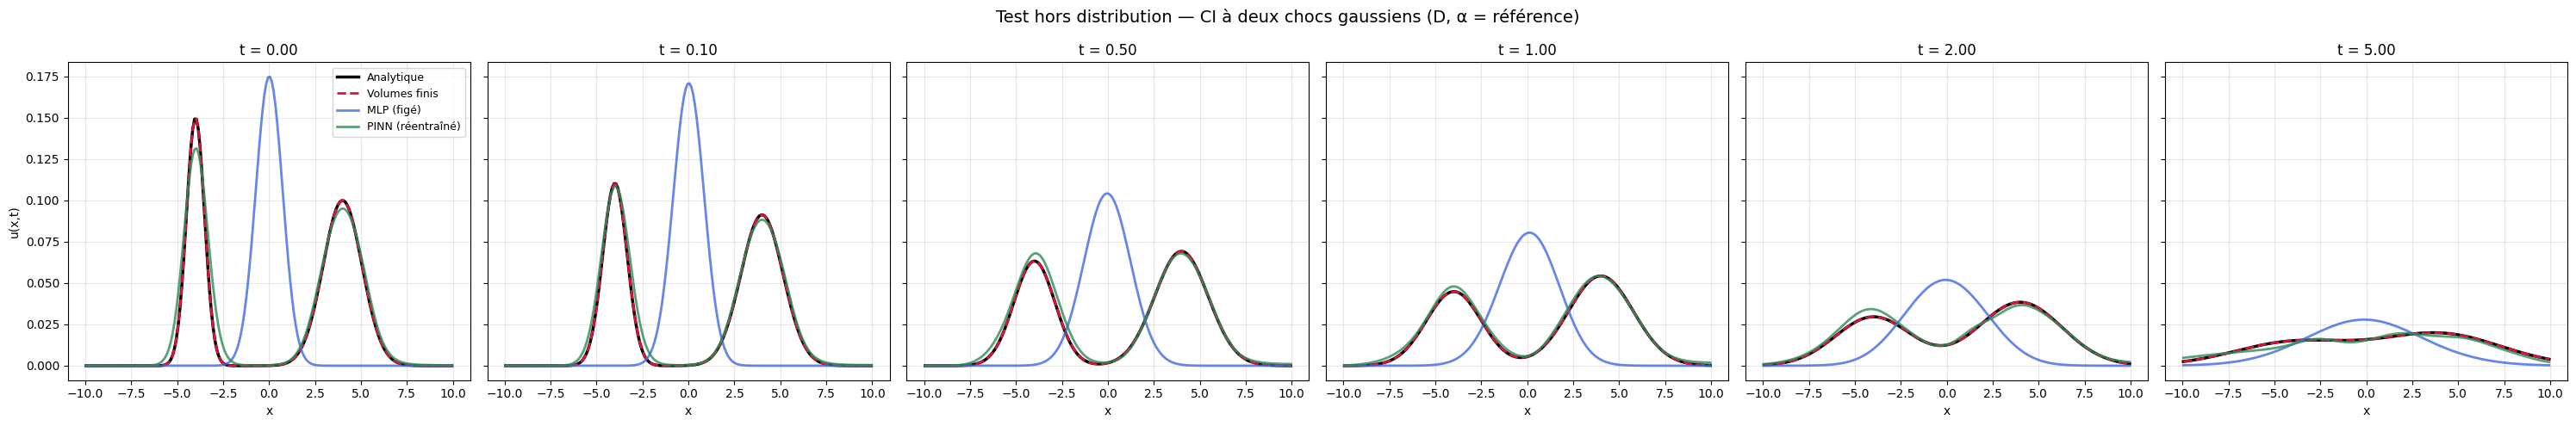

In [31]:
ic_func_ood = lambda x: u_analytique_double_choc(x, 0.0, A1, x1_ood, sigma1, A2, x2_ood, sigma2, D_ood, alpha_ood)
bc_func_ood = lambda xb_, t_: u_analytique_double_choc(xb_, t_, A1, x1_ood, sigma1, A2, x2_ood, sigma2, D_ood, alpha_ood)

t0 = time.perf_counter()
x_VF_ood, t_VF_ood, U_vf_ood = u_volume_finie(D=D_ood, alpha=alpha_ood, L=L, T=T, Nx=Nx,
                                               ic_func=ic_func_ood, bc_func=bc_func_ood)
t_vf_ood = time.perf_counter() - t0

t0 = time.perf_counter()
pinn_ood = train_pinn_double_choc(A1, x1_ood, sigma1, A2, x2_ood, sigma2, D_ood, alpha_ood)
t_pinn_ood = time.perf_counter() - t0

Xg, Tg = np.meshgrid(x_VF_ood, t_VF_ood)
U_exacte_ood = u_analytique_double_choc(Xg, Tg, A1, x1_ood, sigma1, A2, x2_ood, sigma2, D_ood, alpha_ood)

# MLP figé (mêmes stats de normalisation que l'entraînement d'origine)
xn = (Xg.ravel() - x_mean) / x_std
tn = (Tg.ravel() - t_mean) / t_std
Xm_ood = torch.tensor(np.column_stack([xn, tn]), dtype=torch.float32)
model.eval()
with torch.no_grad():
    ul = model(Xm_ood).numpy().flatten() * u_std + u_mean
U_mlp_ood = (np.exp(ul) - eps).reshape(Xg.shape)

pinn_ood.eval()
with torch.no_grad():
    U_pinn_ood = pinn_ood(torch.tensor(np.column_stack([Xg.ravel(), Tg.ravel()]),
                                        dtype=torch.float32)).numpy().reshape(Xg.shape)

def predire_mlp_ood():
    """Prédiction du MLP figé sur la grille OOD (jamais réentraîné)."""
    xn = (Xg.ravel() - x_mean) / x_std
    tn = (Tg.ravel() - t_mean) / t_std
    Xin = torch.tensor(np.column_stack([xn, tn]), dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        ul = model(Xin).numpy().flatten() * u_std + u_mean
    return (np.exp(ul) - eps).reshape(Xg.shape)

def predire_pinn_ood():
    """Prédiction du PINN réentraîné spécifiquement pour cette CI OOD."""
    Xin = torch.tensor(np.column_stack([Xg.ravel(), Tg.ravel()]), dtype=torch.float32)
    pinn_ood.eval()
    with torch.no_grad():
        return pinn_ood(Xin).numpy().reshape(Xg.shape)

U_mlp_ood = predire_mlp_ood()
U_pinn_ood = predire_pinn_ood()

# Le tableau récapitulatif (erreurs + temps d'entraînement/évaluation)
# n'est PAS construit ici : il est fusionné avec celui du régime
# d'entraînement dans LE tableau final unique, en toute fin de notebook
# (section "Tableau final unique").

# --- Tracé -----------------------------------------------------------
temps_a_tracer = [1e-4, 0.1, 0.5, 1, 2, T]
fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5), sharey=True)
for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_VF_ood - ti))
    ue = u_analytique_double_choc(x_VF_ood, t_VF_ood[idx], A1, x1_ood, sigma1, A2, x2_ood, sigma2, D_ood, alpha_ood)
    ax.plot(x_VF_ood, ue, color='black', linewidth=2.5, label="Analytique")
    ax.plot(x_VF_ood, U_vf_ood[idx, :], color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
    ax.plot(x_VF_ood, U_mlp_ood[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP (figé)")
    ax.plot(x_VF_ood, U_pinn_ood[idx, :], color='seagreen', linewidth=2, alpha=0.8, label="PINN (réentraîné)")
    ax.set_title(f"t = {ti:.2f}"); ax.set_xlabel('x'); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('u(x,t)'); axes[0].legend(fontsize=9)
plt.suptitle("Test hors distribution — CI à deux chocs gaussiens (D, α = référence)", fontsize=14)
plt.tight_layout()
plt.savefig('ood_double_choc.png', dpi=200, bbox_inches='tight')
plt.show()

## Test hors distribution — extrapolation temporelle (t > T)

Second test hors distribution, complémentaire du précédent : on ne change PAS la forme de la condition initiale (toujours un seul choc gaussien, celui de l'entraînement), mais on interroge le MLP et le PINN **figés** (aucun réentraînement, contrairement au double choc) sur l'intervalle de temps `t ∈ (T, 2T]`, jamais vu à l'entraînement — y compris par la normalisation du MLP (`t_mean`, `t_std` calés sur `[0, T]`).

Référence : les Volumes Finis, resimulés jusqu'à `2T`, et la solution analytique exacte (toujours valide, la CI et la physique ne changeant pas).

Méthode,RMSE,L∞,L2 max(t)
Volumes finis,3.253e-06,1.115e-05,2.090e-05
"MLP (figé, jamais réentraîné)",6.381e-03,2.278e-02,5.533e-02
"PINN (figé, jamais réentraîné)",1.132e-03,2.927e-03,9.091e-03


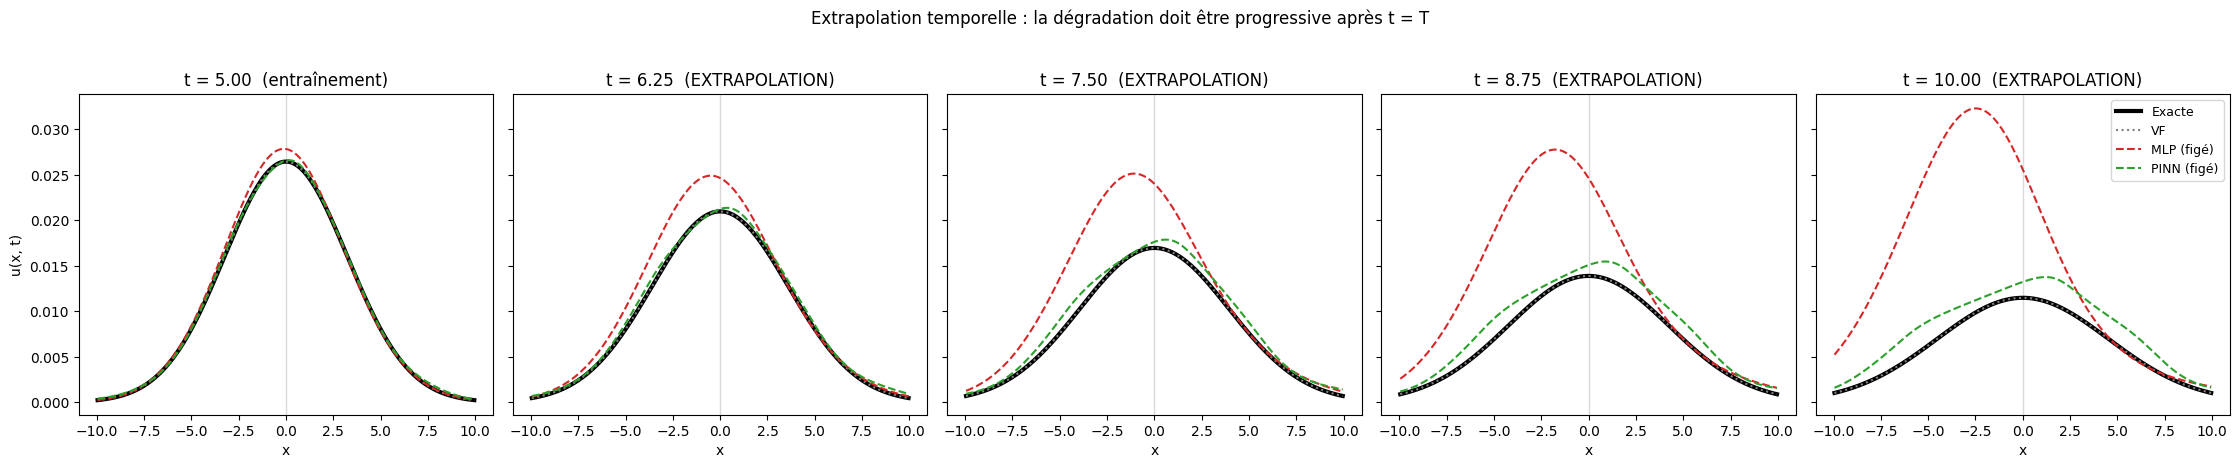

In [32]:

# ============================================================
# TEST HORS DISTRIBUTION : extrapolation temporelle (t > T)
# ============================================================

# --- Référence : Volumes Finis resimulés jusqu'à 2T -----------------------
t0 = time.perf_counter()
x_ext_vf, t_full_vf, U_vf_full = u_volume_finie(
    A=A, x0=x0, sigma=sigma, D=D, alpha=alpha, L=L, T=2*T, Nx=Nx)
t_vf_ext = time.perf_counter() - t0

# --- On ne garde QUE la zone jamais vue : t > T ----------------------------
masque_extrap = t_full_vf > T
t_ext = t_full_vf[masque_extrap]
U_vf_ext = U_vf_full[masque_extrap, :]

Xe, Te = np.meshgrid(x_ext_vf, t_ext)              # (n_t_ext, Nx)
U_exacte_ext = u_analytique(Xe, Te, A, x0, sigma, D, alpha)
dx_ext = x_ext_vf[1] - x_ext_vf[0]

# --- MLP et PINN FIGÉS (aucun réentraînement) : mêmes modèles que ceux ----
#     déjà entraînés et sauvegardés sur [0, T] plus haut dans le notebook.
def predire_mlp_ext():
    """MLP figé, normalisation inchangée (calée sur [0, T])."""
    xn = (Xe.ravel() - x_mean) / x_std
    tn = (Te.ravel() - t_mean) / t_std
    Xin = torch.tensor(np.column_stack([xn, tn]), dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        ul = model(Xin).numpy().flatten() * u_std + u_mean
    return (np.exp(ul) - eps).reshape(Xe.shape)

def predire_pinn_ext():
    """PINN figé (Adam + L-BFGS), aucun point de collocation pour t > T."""
    Xin = torch.tensor(np.column_stack([Xe.ravel(), Te.ravel()]), dtype=torch.float32)
    pinn.eval()
    with torch.no_grad():
        return pinn(Xin).numpy().reshape(Xe.shape)

U_mlp_ext = predire_mlp_ext()
U_pinn_ext = predire_pinn_ext()

def metr_ext(U_pred):
    d = U_pred - U_exacte_ext
    return (np.sqrt(np.mean(d**2)),                       # RMSE
            np.max(np.abs(d)),                             # L∞
            np.sqrt(dx_ext * np.sum(d**2, axis=1)).max())  # L2 max(t)

df_extrap_preview = pd.DataFrame([
    ("Volumes finis", *metr_ext(U_vf_ext)),
    ("MLP (figé, jamais réentraîné)", *metr_ext(U_mlp_ext)),
    ("PINN (figé, jamais réentraîné)", *metr_ext(U_pinn_ext)),
], columns=["Méthode", "RMSE", "L∞", "L2 max(t)"])
display(df_extrap_preview.style.format(
    {"RMSE": "{:.3e}", "L∞": "{:.3e}", "L2 max(t)": "{:.3e}"}).hide(axis="index"))

# --- Visualisation : profils à quelques instants de la zone d'extrapolation
temps_extrap_a_tracer = [T, T + 0.25*T, T + 0.5*T, T + 0.75*T, 2*T]
fig, axes = plt.subplots(1, len(temps_extrap_a_tracer),
                          figsize=(4.5*len(temps_extrap_a_tracer), 4.5), sharey=True)

for ax, ti in zip(axes, temps_extrap_a_tracer):
    idx_full = np.argmin(np.abs(t_full_vf - ti))

    u_exact_ti = u_analytique(x_ext_vf, t_full_vf[idx_full], A, x0, sigma, D, alpha)
    ax.plot(x_ext_vf, u_exact_ti, color="black", linewidth=3, label="Exacte")
    ax.plot(x_ext_vf, U_vf_full[idx_full, :], color="gray", linestyle=":", label="VF")

    xn = (x_ext_vf - x_mean) / x_std
    tn = (np.full_like(x_ext_vf, t_full_vf[idx_full]) - t_mean) / t_std
    Xin = torch.tensor(np.column_stack([xn, tn]), dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        ul = model(Xin).numpy().flatten() * u_std + u_mean
    u_mlp_ti = np.exp(ul) - eps
    ax.plot(x_ext_vf, u_mlp_ti, color="tab:red", linestyle="--", label="MLP (figé)")

    Xin = torch.tensor(np.column_stack(
        [x_ext_vf, np.full_like(x_ext_vf, t_full_vf[idx_full])]), dtype=torch.float32)
    pinn.eval()
    with torch.no_grad():
        u_pinn_ti = pinn(Xin).numpy().flatten()
    ax.plot(x_ext_vf, u_pinn_ti, color="tab:green", linestyle="--", label="PINN (figé)")

    statut = "entraînement" if ti <= T else "EXTRAPOLATION"
    ax.set_title(f"t = {ti:.2f}  ({statut})")
    ax.set_xlabel("x")
    ax.axvline(0, color="0.85", linewidth=1, zorder=0)

axes[0].set_ylabel("u(x, t)")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("Extrapolation temporelle : la dégradation doit être progressive après t = T",
             y=1.03)
plt.tight_layout()
plt.savefig("extrapolation_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()


### test d'epochs et lambda
Ce test a été réalisé afin de déterminer le nombre d’epochs et la valeur de λ permettant d’obtenir les meilleurs résultats.
Chaque configuration testée nécessite environ 2 minutes d’exécution.

In [36]:
def eval_pinn(m, D_s, alpha_s, sigma_s):
    xx, tt = np.meshgrid(np.linspace(-L, L, 200), np.linspace(0, T, 101))
    with torch.no_grad():
        up = m(torch.tensor(np.column_stack([xx.ravel(), tt.ravel()]),
                            dtype=torch.float32)).numpy().reshape(xx.shape)
    d = up - u_analytique(xx, tt, A, x0, sigma_s, D_s, alpha_s)
    return np.sqrt(np.mean(d**2)), np.abs(d).max()

p = scenarios["Front raide"]
rows = []
for ep in [800, 1000, 1500]:
    for sd in [0, 1, 2]:
        t0 = time.perf_counter()
        m = train_pinn_scenario(D=p["D"], alpha=p["alpha"], sigma=p["sigma"],
                                epochs=ep, N_r=500, N_lbfgs=2000, seed=sd)
        r, l = eval_pinn(m, p["D"], p["alpha"], p["sigma"])
        rows.append((ep, sd, r, l, time.perf_counter() - t0))

df_sweep = pd.DataFrame(rows, columns=["epochs", "seed", "RMSE", "Linf", "temps (s)"])
display(df_sweep.groupby("epochs").median().drop(columns="seed"))

,RMSE,Linf,temps (s)
epochs,,,
800,0.003749,0.019428,6.214244
1000,0.003326,0.017690,7.031573
1500,0.002105,0.011128,9.630005


lambda_pde = 3 : compromis retenu après comparaison sur plusieurs seeds
(cf. tableau median/max RMSE et Linf, scénarios "Diffusion rapide" et
"Front raide"). Ce n'est le meilleur sur AUCUNE métrique individuelle :
lambda=8 minimise la RMSE médiane mais fait exploser le Linf max
(jusqu'à x3 sur "Diffusion rapide") ; lambda=1.5 est plus sûr en pire cas
mais moins bon en moyenne. lambda=3 est le seul qui reste dans le top 2
sur les deux scénarios et les deux métriques simultanément -- un choix
de robustesse plutôt qu'un optimum ponctuel.

In [34]:
rows = []
for nom_s in ["Front raide", "Diffusion rapide"]:
    p = scenarios[nom_s]
    for lam in [8.0, 3.0, 1.5,4.0]:
        for sd in range(3):
            m = train_pinn_scenario(D=p["D"], alpha=p["alpha"], sigma=p["sigma"],
                                    epochs=1000, lambda_pde=lam, N_ic=600, N_bc=300,
                                    N_r=500, N_lbfgs=2000, seed=sd)
            r, l = eval_pinn(m, p["D"], p["alpha"], p["sigma"])
            rows.append((nom_s, lam, sd, r, l))

df_lam = pd.DataFrame(rows, columns=["scénario", "lambda_pde", "seed", "RMSE", "Linf"])
display(df_lam.groupby(["scénario", "lambda_pde"])[["RMSE", "Linf"]]
        .agg(["median", "max"]).style.format("{:.2e}"))